## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA

import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from os.path import join
import pandas as pd
np.random.seed(0)

In [2]:
# 读取encoded数据
# import zipfile
# data_path = '/home/lqr/CLIMA/datasets/new_simu/encoded'
# with zipfile.ZipFile(join(data_path, 'autoencoder.zip'), 'r') as zip_ref:
#     # for name in zip_ref.namelist():
#     #     print(name)
#     with zip_ref.open('autoencoder/GSE140203_mouse_skin_Gene_normalized_downsampling_encoded.csv') as file:
#         data1 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder/GSE140203_mouse_skin_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data2 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder/GSE140203_mouse_skin_Gene_plus_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data3 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder/GSE140203_mouse_skin_Gene_times_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data4 = pd.read_csv(file, index_col=0)
# 保存为npz文件
# np.savez(join(data_path, 'skin_normalized.npz'), gene=data1.values, peak=data2.values, gene_plus_peak=data3.values, gene_times_peak=data4.values)


In [3]:

data_path = '/home/lqr/CLIMA/datasets/new_simu/skin_sample'
data = np.load(join(data_path, 'skin_normalized.npz'))
all_gene = data['gene']
all_peak = data['peak']
# gene = data['gene']
# peak = data['peak']
# gene_peak = data['gene_plus_peak']
# all_gene_peak = data['gene_times_peak']


In [4]:
gene = all_gene[:2500, :]
peak = all_peak[:2500, :]
print(all_gene.shape)
print(all_peak.shape)
print(gene.shape)
print(peak.shape)

(4531, 23296)
(4531, 23296)
(2500, 23296)
(2500, 23296)


In [5]:
# gene_peak = gene * peak
gene_peak = gene + peak
# gene_peak = (gene + 1) * (peak + 1)

## Generate simulation data

In [6]:
print(f"gene_sum: {np.sum(gene)}")
print(f"peak_sum: {np.sum(peak)}")
# 找出所有值都为空的列
gene_empty_cols = np.all(gene == 0, axis=0)
peak_empty_cols = np.all(peak == 0, axis=0)
print(f"gene_empty_cols: {np.sum(gene_empty_cols)}")
print(f"peak_empty_cols: {np.sum(peak_empty_cols)}")

gene_sum: 3854851.299286427
peak_sum: 897352.7296186143
gene_empty_cols: 4241
peak_empty_cols: 21878



Simulation parameters



Use simulation tool to generate multi-modality data

## Analyses based on single modality

Learn features from single modality

In [7]:
latent_dim = 100
view_gene_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(gene)
view_peak_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(peak)
view_ab_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(gene_peak)

In [8]:
print(f"gene.shape: {gene.shape}")
print(f"peak.shape: {peak.shape}")
print(f"view_gene_feature.shape: {view_gene_feature.shape}")
print(f"view_peak_feature.shape: {view_peak_feature.shape}")

gene.shape: (2500, 23296)
peak.shape: (2500, 23296)
view_gene_feature.shape: (2500, 100)
view_peak_feature.shape: (2500, 100)


Perform clustering using PhenoGraph

In [9]:
view_a_label, _, _ = phenograph.cluster(view_gene_feature, random_state=42)
view_b_label, _, _ = phenograph.cluster(view_peak_feature, random_state=42)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm


Neighbors computed in 0.10473942756652832 seconds
Jaccard graph constructed in 0.29237794876098633 seconds
Wrote graph to binary file in 0.013849258422851562 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.728007
After 3 runs, maximum modularity is Q = 0.72953
After 7 runs, maximum modularity is Q = 0.730756
Louvain completed 27 runs in 0.6440563201904297 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.2311289310455322 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0782010555267334 seconds
Jaccard graph constructed in 0.24394989013671875 seconds
Wrote graph to binary file in 0.012974262237548828 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.573161
After 2 runs, maximum modularity is Q = 0.577221
After 5 runs, maximum modularity is Q = 0.579657
Louvain completed 25 runs in 0.702831506729126 seconds
Sorting communit

In [10]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_gene_feature)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_peak_feature)
XY_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_ab_feature)

X_embedded: (2500, 2)
label_true: (2500,)


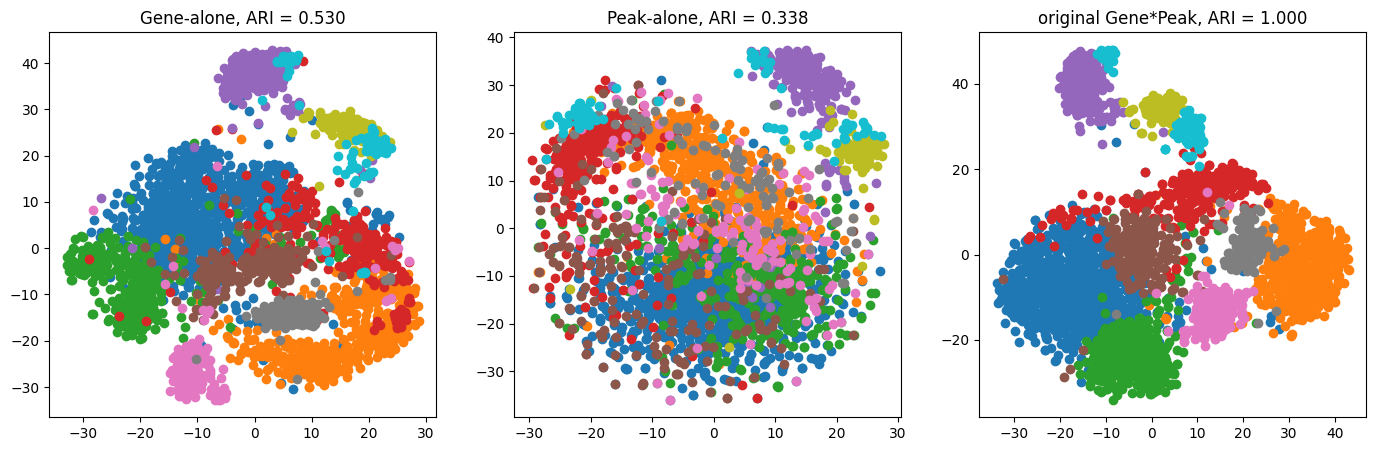

In [11]:
plt.figure(figsize=(17, 5))
# Gene-alone
plt.subplot(1, 3, 1)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {view_ab_label.shape}")
# 遍历每一个类别
for i in np.unique(view_ab_label):
    # 找到所有类别为i的索引
    idx = np.nonzero(view_ab_label == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Gene-alone, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_a_label))

# Peak-alone
plt.subplot(1, 3, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('Peak-alone, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_b_label))

# original Gene+Peak
plt.subplot(1, 3, 3)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('original Gene*Peak, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_ab_label))

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [151]:
outputs = muse.dual_muse_fit_predict(
    [gene, peak],
    [gene_peak],
    [view_a_label, view_b_label],
    [view_ab_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=10,
    weight_penalty=1,
    triplet_lambda=1,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++


#epoch: 0/200 	 total loss: 267.42 	 sc loss: 139.64 	 st loss: 99.48 	 infoNCE: 28.30 	 sc recon: 0.12 	 st recon: 0.10 	 sc sparse: 139.52 	 st sparse: 99.38 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 50/200 	 total loss: 203.84 	 sc loss: 118.71 	 st loss: 84.67 	 infoNCE: 0.46 	 sc recon: 0.01 	 st recon: 0.03 	 sc sparse: 118.70 	 st sparse: 84.64 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 100/200 	 total loss: 171.38 	 sc loss: 99.86 	 st loss: 71.31 	 infoNCE: 0.21 	 sc recon: 0.01 	 st recon: 0.03 	 sc sparse: 99.85 	 st sparse: 71.28 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 150/200 	 total loss: 142.20 	 sc loss: 82.85 	 st loss: 59.22 	 infoNCE: 0.13 	 sc recon: 0.01 	 st recon: 0.03 	 sc sparse: 82.84 	 st sparse: 59.20 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 0/200 	 total loss: 134.07 	 sc loss: 72.11 	 st loss: 51.27 	 infoNCE: 10.69 	 sc recon: 0.02 	 st recon: 0.03 	 sc sparse: 67.69 	 st sparse: 48.41 	 sc trip: 4.40 	 st trip: 2.83
#epoch: 50/200 	 total loss: 96.19 	 sc loss

In [152]:
latent_sc = (outputs[0])
latent_st = (outputs[1])
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {reconstruct_sc.shape}")
print(f"reconstruct_st: {reconstruct_st.shape}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (2500, 100)
latent_st: (2500, 100)
reconstruct_sc: (2, 2500, 23296)
reconstruct_st: (1, 2500, 23296)
encoded_sc: (2, 2500, 128)
encoded_st: (1, 2500, 128)


## Perform clustering
PhenoGraph clustering

In [153]:
latent_label_sc, _, _ = phenograph.cluster(latent_sc, random_state=42)
latent_label_st, _, _ = phenograph.cluster(latent_st, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07746410369873047 seconds
Jaccard graph constructed in 0.8395042419433594 seconds
Wrote graph to binary file in 0.01005244255065918 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.819778
Louvain completed 21 runs in 1.6863131523132324 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 3.409792423248291 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07694506645202637 seconds
Jaccard graph constructed in 0.8753476142883301 seconds
Wrote graph to binary file in 0.011038780212402344 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.895187
Louvain completed 21 runs in 1.5033037662506104 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 3.2343387603759766 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

In [154]:
latent_X_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
latent_Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_st)

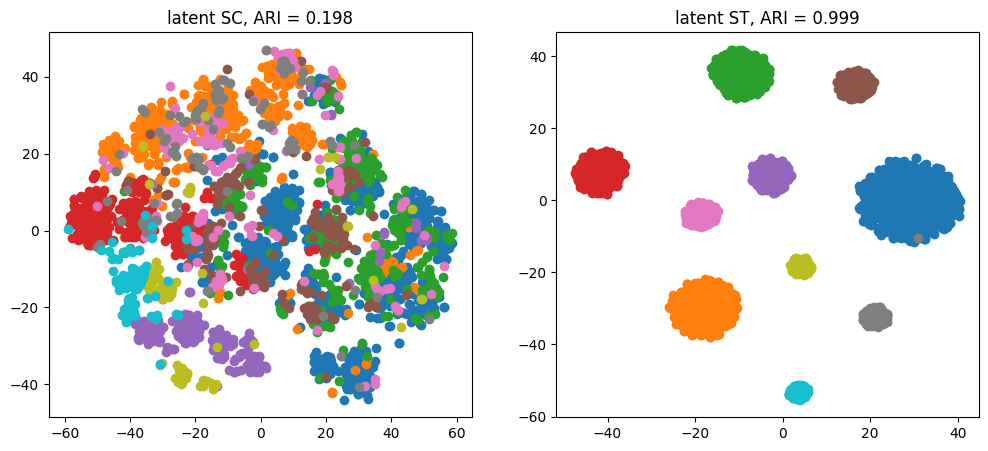

In [155]:
plt.figure(figsize=(12, 5))
# Gene, Peak MUSE(latent sc)
plt.subplot(1, 2, 1)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(latent_X_embedded[idx, 0], latent_X_embedded[idx, 1])
    plt.title('latent SC, ARI = %01.3f' % adjusted_rand_score(view_ab_label, latent_label_sc))

# Peak+Gene MUSE(latent st)
plt.subplot(1, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(latent_Y_embedded[idx, 0], latent_Y_embedded[idx, 1])
    plt.title('latent ST, ARI = %01.3f' % adjusted_rand_score(view_ab_label, latent_label_st))

plt.show()

In [156]:
print('[gene, peak] and [gene+peak] ARI: ', adjusted_rand_score(latent_label_sc, latent_label_st))

[gene, peak] and [gene+peak] ARI:  0.19833709453409645


In [191]:
# PCA降维
latent_sc = PCA(n_components=100, random_state=42).fit_transform(all_gene[2500:, :])
latent_st = PCA(n_components=100, random_state=42).fit_transform(all_peak[2500:, :])
# 训练的输出
# latent_sc = outputs[0]
# latent_st = outputs[1]
# 未训练
# latent_sc = gene
# latent_st = peak
# 预测的输出
# latent_sc = out[0][0].cpu().numpy()
# latent_st = out[0][1].cpu().numpy()

**************************************************
S: torch.Size([2031, 100, 1])
G: torch.Size([2031, 100, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

 12%|█▏        | 61/500 [00:00<00:03, 111.55it/s]

Epoch 50: Loss -1.9988937377929688


 22%|██▏       | 112/500 [00:00<00:03, 114.42it/s]

...

Epoch 400: Loss -2.0


 94%|█████████▍| 472/500 [00:03<00:00, 202.46it/s]

Epoch 450: Loss -2.0


100%|██████████| 500/500 [00:03<00:00, 125.27it/s]

Epoch 500: Loss -2.0
[[-1.4313931   1.7541374   2.414332   ...  0.28189152 -0.04509617
   1.443568  ]
 [-0.9460558   0.51064515 -0.9303041  ...  2.4459937  -0.36345768
  -1.6807815 ]
 [-1.6362106   0.5764176   0.4117974  ...  1.5338515  -2.2579205
  -0.41869274]
 ...
 [ 0.48049602  1.0956842  -0.07655225 ... -0.5621418   0.67346585
   0.5489369 ]
 [ 1.262355   -2.755882    0.1870501  ... -0.7956465   2.7851686
  -0.03070669]
 [-2.9826157  -1.7464944  -0.7147187  ...  0.6402681   0.2880671
   1.3644508 ]]


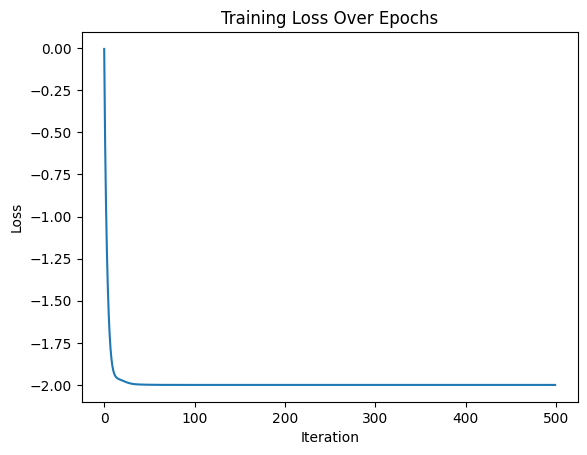

In [192]:
from sim_tangram.train_tangram import read_csv_and_run_tangram
import torch

# tangram
tangram_sim, _ = read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    # [torch.tensor(view_c_feature, device='cuda:0', dtype=torch.float32)],
    # [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=50,
    lambda_g1=1,
    lambda_g2=1
)

In [193]:
# import org_cca.train_tangram

# cca_sim, _ = org_cca.train_tangram.read_csv_and_run_tangram(
#     [torch.tensor(latent_sc, device='cuda:0', dtype=torch.float32)],
#     [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
#     num_epochs=500,
#     print_interval=500,
#     spotwise=True,
#     genewise=True,
# )

**************************************************
S: torch.Size([2031, 100, 1])
G: torch.Size([2031, 100, 1])


 13%|█▎        | 63/500 [00:00<00:00, 629.67it/s]

100%|██████████| 500/500 [00:00<00:00, 627.50it/s]


Epoch 500: Loss -2.0
[[-1.4272503   1.8072158   2.3671014  ...  0.29021728 -0.01669835
   1.4466984 ]
 [-0.95197403  0.5226031  -0.9046026  ...  2.446549   -0.27751246
  -1.6626374 ]
 [-1.6332271   0.5812266   0.1644013  ...  1.5327368  -2.2324884
  -0.4117511 ]
 ...
 [ 0.44645917  1.0990671  -0.08843365 ... -0.56344056  0.65494275
   0.5376572 ]
 [ 1.2663773  -2.7625582   0.20880824 ... -0.7799272   2.786556
  -0.03901388]
 [-2.9789631  -1.7386897  -0.49807245 ...  0.6459197   0.29441136
   1.3600342 ]]


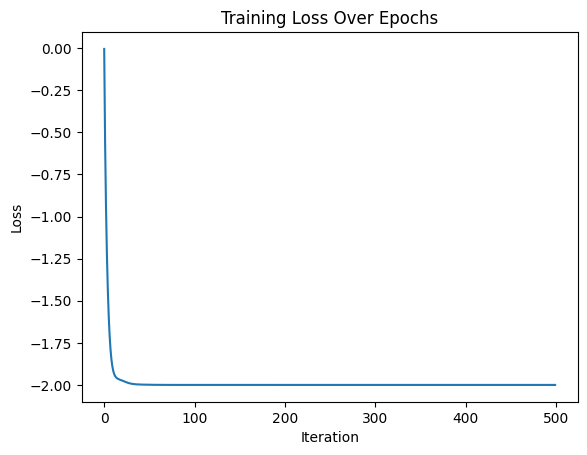

In [194]:
# 用cosine_similarity驱动的tangram进行计算

import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [195]:
# tangram cosine_similarity
cos_tg_mapping = cos_sim_tg.argmax(axis=1)

# # org tangram cca
# org_cca_mapping = cca_sim.argmax(axis=1)
# tangram cca
mapping = tangram_sim.argmax(axis=1)
for i in range(len(mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {mapping[i]:4d}", end="\t")

# cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")



 0:  819	 1: 1826	 2: 1658	 3: 1521	 4:  344	
 5: 1536	 6:  602	 7: 1175	 8: 1667	 9: 1988	
10:   49	11:  463	12: 1795	13:  142	14:  495	
15:  779	16: 1282	17:   99	18: 1803	19: 1643	
20:  639	21:  651	22:  914	23:  760	24:  654	
25: 1293	26: 1499	27:   86	28:  594	29:  835	
 0: 1982	 1:  921	 2: 1929	 3:  626	 4: 1280	
 5: 1209	 6: 1930	 7: 1051	 8:  921	 9:  255	
10: 1125	11:  626	12:  626	13: 1766	14: 1930	
15:  335	16: 1153	17: 1225	18: 1071	19:  995	
20:  560	21: 1084	22: 1696	23: 1703	24: 1084	
25: 1839	26: 1225	27: 1839	28: 1395	29:  748	

In [196]:
sample_size = tangram_sim.shape[0]
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
print("cos accuracy:", cos_acc)
tangram_acc = np.sum(mapping == gt) / sample_size
print("tangram cca accuracy:", tangram_acc)
# cca_acc = np.sum(org_cca_mapping == gt) / sample_size
# print("org tangram cca accuracy:", cca_acc)
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos_tg accuracy:", cos_tg_acc)


cos accuracy: 0.0004923682914820286
tangram cca accuracy: 0.0004923682914820286
cos_tg accuracy: 0.0004923682914820286


: 

In [163]:
model = outputs[6]

In [164]:
print(view_a_label.shape)
print(view_ab_label.shape)
print(all_gene.shape)
print(all_peak.shape)


(2500,)
(2500,)
(4531, 23296)
(4531, 23296)


In [172]:
from multi_muse_sc import *

with torch.no_grad():
    data_inputs_tensor_sc = get_all_tensor(
        [all_gene[2500:], all_peak[2500:]]
    )
    data_inputs_tensor_st = get_all_tensor(
        [all_gene[2500:] + all_peak[2500:]]
    )
    out = model(
        data_inputs_tensor_sc,
        data_inputs_tensor_st,
        info_nce_lambda=1,
    )